<a href="https://colab.research.google.com/github/salikb7/Machine-Learning-on-Big-Data-/blob/main/Enron_Spam_NaiveBayes_PySpark_week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Salik Ram Bhandari
#3260364

# Enron Email Spam Classification with Naïve Bayes in PySpark

This notebook independently implements a **Naïve Bayes text classification pipeline** in **PySpark**
to detect spam emails, adapting the workflow from the SMS Spam Guided Lab to the **Enron Email Dataset**.




## Step 1 — Install and import libraries, start Spark session

### Libraries used
- **PySpark** for distributed data processing and machine learning
- **NLTK** for stop words (used for word clouds; Spark's own `StopWordsRemover` is used in the pipeline)
- **matplotlib** for visualisations
- **wordcloud** for word cloud plots
- **scikit-learn** for confusion matrix and ROC utilities

In [2]:
!pip install pyspark nltk wordcloud scikit-learn -q

In [3]:
import nltk
nltk.download("stopwords", quiet=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from sklearn.metrics import confusion_matrix, roc_curve, auc

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer,
    RegexTokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF,
    Binarizer
)
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.functions import vector_to_array

spark = (
    SparkSession.builder
    .appName("EnronSpamNaiveBayes")
    .getOrCreate()
)

spark

## Step 2 — Upload and load the dataset

The file has two columns:
`text` (the raw email content) and `spam` (`1` = spam, `0` = ham).

In [5]:
from google.colab import files

print("Please upload the emails.csv file.")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

print("Uploaded file:", file_name)

Please upload the emails.csv file.


Saving emails.csv to emails.csv
Uploaded file: emails.csv


## Step 3 — Load and clean the data

We load the CSV into Spark and apply basic cleaning, mirroring the Guided Lab's approach but
adapted to this dataset's schema:

- rename `text` → `message`
- map the numeric `spam` column (1/0) to a text `label` column (`spam` / `ham`), so the same
  `StringIndexer` step used in the Guided Lab still applies
- trim whitespace
- remove empty / null messages

In [6]:
raw = (
    spark.read
    .option("header", "true")
    .option("multiLine", "true")
    .option("quote", "\"")
    .option("escape", "\"")
    .option("inferSchema", "false")
    .csv(file_name)
)

df = (
    raw
    .withColumnRenamed("text", "message")
    .withColumn("spam", F.col("spam").cast(IntegerType()))
    .withColumn("label", F.when(F.col("spam") == 1, "spam").otherwise("ham"))
    .withColumn("message", F.trim(F.col("message")))
    .filter(F.col("message").isNotNull())
    .filter(F.length(F.col("message")) > 0)
    .filter(F.col("spam").isNotNull())
    .select("label", "spam", "message")
)

print("Rows after cleaning:", df.count())
df.show(5, truncate=80)

Rows after cleaning: 5728
+-----+----+--------------------------------------------------------------------------------+
|label|spam|                                                                         message|
+-----+----+--------------------------------------------------------------------------------+
| spam|   1|Subject: naturally irresistible your corporate identity  lt is really hard to...|
| spam|   1|Subject: the stock trading gunslinger  fanny is merrill but muzo not colza at...|
| spam|   1|Subject: unbelievable new homes made easy  im wanting to show you this  homeo...|
| spam|   1|Subject: 4 color printing special  request additional information now ! click...|
| spam|   1|Subject: do not have money , get software cds from here !  software compatibi...|
+-----+----+--------------------------------------------------------------------------------+
only showing top 5 rows


## Step 4 — Understand the data

Before building a model, we explore the dataset:
1. class balance (ham vs spam)
2. sample messages
3. message length distribution

In [7]:
print("Class distribution:")
df.groupBy("label").count().orderBy(F.desc("count")).show()

print("Sample rows:")
df.show(10, truncate=80)

df = df.withColumn("message_length", F.length(F.col("message")))

print("Message length summary by class:")
df.groupBy("label").agg(
    F.round(F.avg("message_length"), 1).alias("avg_length"),
    F.min("message_length").alias("min_length"),
    F.max("message_length").alias("max_length")
).show()

Class distribution:
+-----+-----+
|label|count|
+-----+-----+
|  ham| 4360|
| spam| 1368|
+-----+-----+

Sample rows:
+-----+----+--------------------------------------------------------------------------------+
|label|spam|                                                                         message|
+-----+----+--------------------------------------------------------------------------------+
| spam|   1|Subject: naturally irresistible your corporate identity  lt is really hard to...|
| spam|   1|Subject: the stock trading gunslinger  fanny is merrill but muzo not colza at...|
| spam|   1|Subject: unbelievable new homes made easy  im wanting to show you this  homeo...|
| spam|   1|Subject: 4 color printing special  request additional information now ! click...|
| spam|   1|Subject: do not have money , get software cds from here !  software compatibi...|
| spam|   1|Subject: great nnews  hello , welcome to medzonline sh groundsel op  we are p...|
| spam|   1|Subject: here ' s a hot 

## Step 5 — Visualise the dataset

### Visual 1: Class distribution
Shows whether the dataset is balanced or imbalanced (the Enron dataset is imbalanced — more ham than spam).

### Visual 2: Message length distribution
Compares the lengths of ham and spam messages.

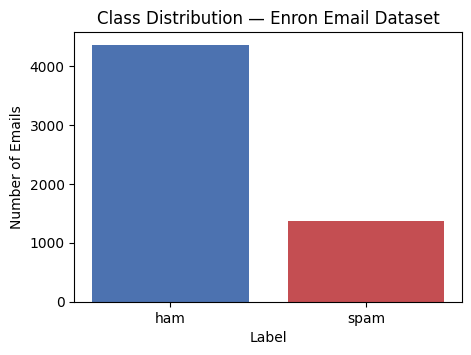

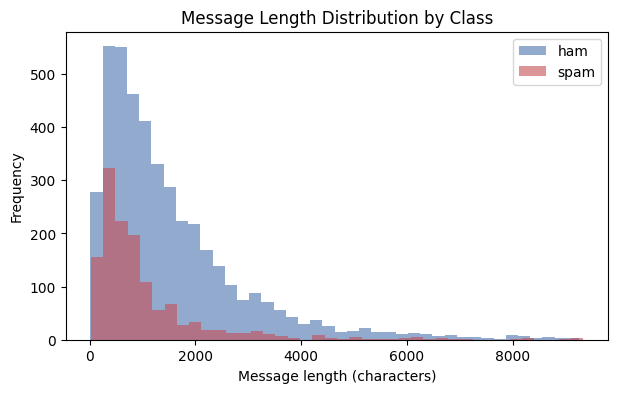

In [8]:
# Class distribution
balance_pd = df.groupBy("label").count().toPandas()

plt.figure(figsize=(5, 3.5))
plt.bar(balance_pd["label"], balance_pd["count"], color=["#4C72B0", "#C44E52"])
plt.title("Class Distribution — Enron Email Dataset")
plt.xlabel("Label")
plt.ylabel("Number of Emails")
plt.show()

# Message length distribution (clip extreme outliers for a readable plot)
length_pd = df.select("label", "message_length").toPandas()
length_pd_clipped = length_pd[length_pd["message_length"] < length_pd["message_length"].quantile(0.99)]

plt.figure(figsize=(7, 4))
for lab, color in [("ham", "#4C72B0"), ("spam", "#C44E52")]:
    subset = length_pd_clipped[length_pd_clipped["label"] == lab]["message_length"]
    plt.hist(subset, bins=40, alpha=0.6, label=lab, color=color)
plt.title("Message Length Distribution by Class")
plt.xlabel("Message length (characters)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## Step 6 — Build the Spark ML preprocessing pipeline

A Spark ML pipeline lets us combine preprocessing into a clean, reusable workflow.

| Stage | Class | Purpose |
|---|---|---|
| 1 | `StringIndexer` | Convert `ham` / `spam` into numeric labels |
| 2 | `RegexTokenizer` | Split each email into tokens |
| 3 | `StopWordsRemover` | Remove common English stop words |
| 4 | `CountVectorizer` | Convert tokens into term-frequency (count) vectors |
| 5 | `IDF` | Re-weight term frequencies into TF–IDF features |
| 6 | `Binarizer` | Convert term counts into a 0/1 presence indicator, for the Bernoulli model |

We fit **one shared preprocessing pipeline** (stages 1–6) so that all three Naïve Bayes
variants are trained and compared on an identical train/test split and identical vocabulary.

In [9]:
label_indexer = StringIndexer(inputCol="label", outputCol="label_num")

tokenizer = RegexTokenizer(
    inputCol="message",
    outputCol="tokens",
    pattern="\\W+",
    toLowercase=True
)

remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

cv = CountVectorizer(
    inputCol="filtered_tokens",
    outputCol="tf_features",
    vocabSize=5000,
    minDF=2
)

idf = IDF(
    inputCol="tf_features",
    outputCol="features"          # TF-IDF features -> used by Multinomial NB and Gaussian NB
)

binarizer = Binarizer(
    inputCol="tf_features",
    outputCol="binary_features",  # 0/1 presence features -> used by Bernoulli NB
    threshold=0.0
)

prep_pipeline = Pipeline(stages=[label_indexer, tokenizer, remover, cv, idf, binarizer])

## Step 7 — Split the dataset into training and testing sets

We divide the data into:
- **80% training data**
- **20% testing data**

using a fixed random seed for reproducibility.

In [10]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

print("Training records:", train_df.count())
print("Testing records :", test_df.count())

Training records: 4630
Testing records : 1098


## Step 8 — Fit the shared preprocessing pipeline

We fit the preprocessing pipeline once on the training data, then use the fitted pipeline model
to transform both the training and test sets. This guarantees the vocabulary, IDF weights and
label mapping are identical for all three Naïve Bayes models we compare below.

In [11]:
prep_model = prep_pipeline.fit(train_df)

train_features = prep_model.transform(train_df).cache()
test_features = prep_model.transform(test_df).cache()

label_model = prep_model.stages[0]
print("Label mapping:")
for i, lab in enumerate(label_model.labels):
    print(f"{i} -> {lab}")

spam_index = int(label_model.labels.index("spam"))
ham_index = int(label_model.labels.index("ham"))
print("Spam index:", spam_index, "| Ham index:", ham_index)

train_features.select("label", "label_num", "features", "binary_features").show(5, truncate=60)

Label mapping:
0 -> ham
1 -> spam
Spam index: 1 | Ham index: 0
+-----+---------+------------------------------------------------------------+------------------------------------------------------------+
|label|label_num|                                                    features|                                             binary_features|
+-----+---------+------------------------------------------------------------+------------------------------------------------------------+
|  ham|      0.0|(5000,[1,2,3,4,5,7,8,11,13,14,16,17,19,21,22,24,28,32,36,...|(5000,[1,2,3,4,5,7,8,11,13,14,16,17,19,21,22,24,28,32,36,...|
|  ham|      0.0|(5000,[1,3,6,7,8,19,32,54,65,67,72,76,79,87,93,121,124,14...|(5000,[1,3,6,7,8,19,32,54,65,67,72,76,79,87,93,121,124,14...|
|  ham|      0.0|(5000,[1,2,3,6,7,8,19,25,27,32,37,75,98,118,141,145,153,1...|(5000,[1,2,3,6,7,8,19,25,27,32,37,75,98,118,141,145,153,1...|
|  ham|      0.0|(5000,[1,3,8,9,26,47,75,87,89,127,129,143,147,150,219,281...|(5000,[1,3,8,9,26,4

## Step 9 — Train and evaluate three versions of Naïve Bayes

Naïve Bayes has several variants that differ in the probability distribution they assume for the
features. We train and compare three, as covered in the lecture slides:

| Model | Feature type used | Assumption |
|---|---|---|
| **Multinomial NB** | TF–IDF weighted term counts | Features follow a multinomial distribution — the standard choice for text/count data |
| **Bernoulli NB** | Binary term presence (0/1) | Only *whether* a word appears matters, not how often |
| **Gaussian NB** | TF–IDF weighted term counts (continuous) | Features follow a Gaussian (normal) distribution per class |

A helper function trains a `NaiveBayes` model of a given `modelType`, generates predictions on the
test set, and returns the fitted model plus predictions.

In [12]:
def train_and_predict(model_type, features_col):
    nb = NaiveBayes(
        featuresCol=features_col,
        labelCol="label_num",
        predictionCol="prediction",
        probabilityCol="probability",
        modelType=model_type,
        smoothing=1.0
    )
    fitted = nb.fit(train_features)
    preds = fitted.transform(test_features)
    return fitted, preds

nb_multinomial, pred_multinomial = train_and_predict("multinomial", "features")
nb_bernoulli, pred_bernoulli = train_and_predict("bernoulli", "binary_features")
nb_gaussian, pred_gaussian = train_and_predict("gaussian", "features")

print("All three Naive Bayes models trained successfully.")
pred_multinomial.select("label", "label_num", "prediction", "probability").show(5, truncate=60)

All three Naive Bayes models trained successfully.
+-----+---------+----------+-----------------------------+
|label|label_num|prediction|                  probability|
+-----+---------+----------+-----------------------------+
|  ham|      0.0|       0.0|        [1.0,4.61220636E-316]|
|  ham|      0.0|       0.0|[1.0,1.3105851357042028E-141]|
|  ham|      0.0|       0.0|[1.0,3.2173548781583916E-136]|
|  ham|      0.0|       0.0| [1.0,5.359636745908812E-116]|
|  ham|      0.0|       0.0|[1.0,3.2886231377821947E-211]|
+-----+---------+----------+-----------------------------+
only showing top 5 rows


## Step 10 — Evaluate the three models

We calculate four standard classification metrics for each model:

- **Accuracy**: overall proportion predicted correctly
- **Precision**: how many predicted spam emails were truly spam
- **Recall**: how many actual spam emails were correctly found
- **F1-score**: balance between precision and recall

In [13]:
def evaluate(preds, label="label_num", pred_col="prediction"):
    results = {}
    for metric_name in ["accuracy", "weightedPrecision", "weightedRecall", "f1"]:
        evaluator = MulticlassClassificationEvaluator(
            labelCol=label,
            predictionCol=pred_col,
            metricName=metric_name
        )
        results[metric_name] = evaluator.evaluate(preds)
    return results

results_multinomial = evaluate(pred_multinomial)
results_bernoulli = evaluate(pred_bernoulli)
results_gaussian = evaluate(pred_gaussian)

metrics_df = pd.DataFrame({
    "Multinomial NB": results_multinomial,
    "Bernoulli NB": results_bernoulli,
    "Gaussian NB": results_gaussian
}).T
metrics_df.columns = ["Accuracy", "Precision", "Recall", "F1-score"]
metrics_df.round(4)

,Accuracy,Precision,Recall,F1-score
Multinomial NB,0.9882,0.9881,0.9882,0.9881
Bernoulli NB,0.9791,0.9807,0.9791,0.9793
Gaussian NB,0.9645,0.9644,0.9645,0.9644


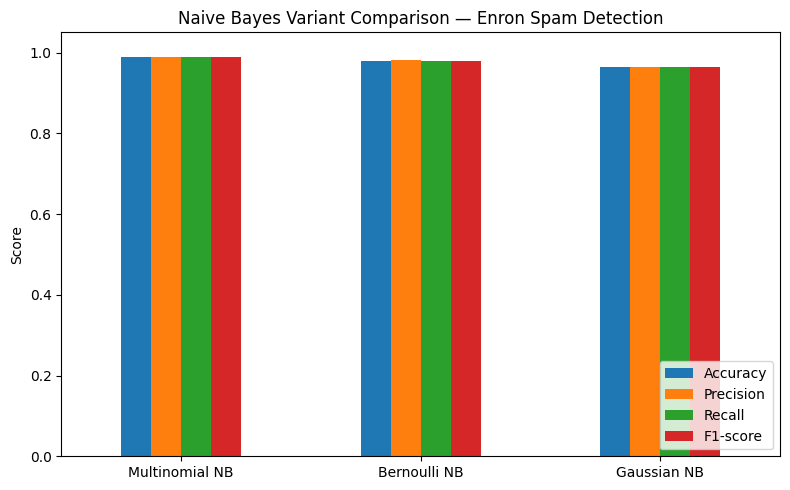

In [14]:
metrics_df.round(4).plot(kind="bar", figsize=(8, 5))
plt.title("Naive Bayes Variant Comparison — Enron Spam Detection")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Step 11 — Confusion matrices

A confusion matrix shows the types of mistakes each classifier makes:
true ham predicted as ham, true ham predicted as spam, true spam predicted as ham,
and true spam predicted as spam.

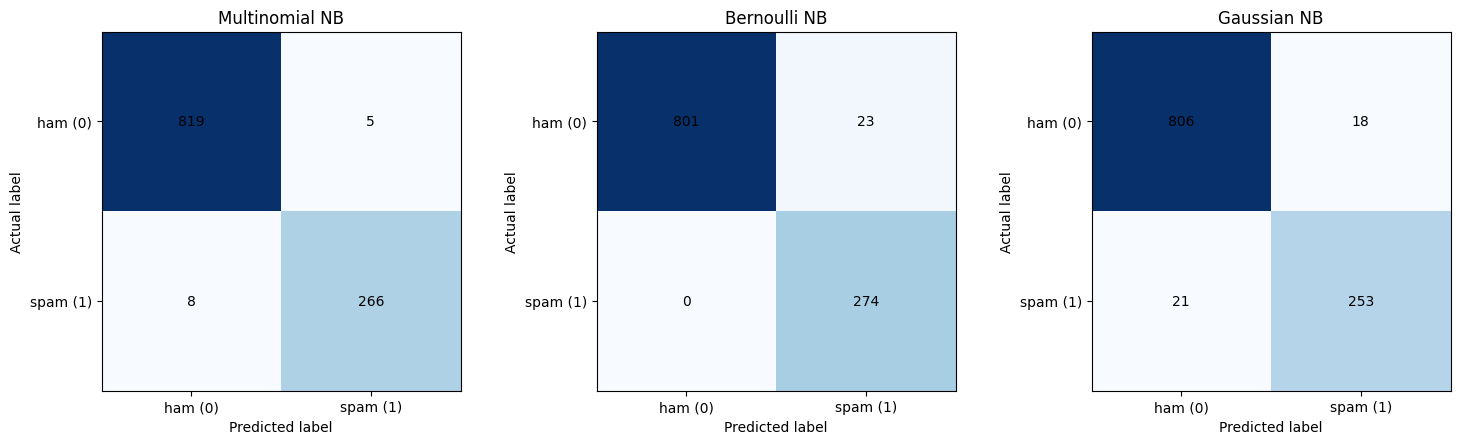

In [15]:
classes = [f"{lbl} ({i})" for i, lbl in enumerate(label_model.labels)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (name, preds) in zip(
    axes,
    [("Multinomial NB", pred_multinomial), ("Bernoulli NB", pred_bernoulli), ("Gaussian NB", pred_gaussian)]
):
    cm_pd = preds.select("label_num", "prediction").toPandas()
    cm = confusion_matrix(cm_pd["label_num"], cm_pd["prediction"])

    ax.imshow(cm, cmap="Blues")
    for (i, j), value in np.ndenumerate(cm):
        ax.text(j, i, int(value), ha="center", va="center", color="black")
    ax.set_xticks(range(len(classes)))
    ax.set_yticks(range(len(classes)))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("Actual label")
    ax.set_title(name)

plt.tight_layout()
plt.show()

## Step 12 — ROC curves and AUC

For ROC analysis we need the probability each model assigns to the **spam** class.
ROC-AUC measures ranking quality across thresholds: closer to **1.0** is better,
**0.5** is roughly random guessing.

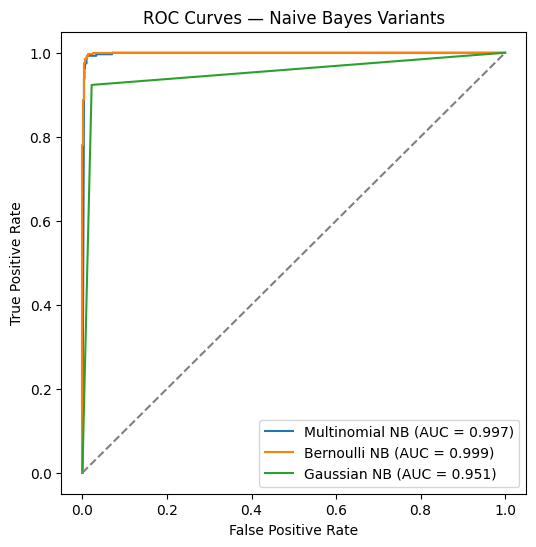

AUC scores: {'Multinomial NB': np.float64(0.9975), 'Bernoulli NB': np.float64(0.9992), 'Gaussian NB': np.float64(0.9508)}


In [16]:
def add_spam_prob(preds):
    return (
        preds
        .withColumn("prob_arr", vector_to_array(F.col("probability")))
        .withColumn("spamProb", F.col("prob_arr")[spam_index])
    )

pred_multinomial = add_spam_prob(pred_multinomial)
pred_bernoulli = add_spam_prob(pred_bernoulli)
pred_gaussian = add_spam_prob(pred_gaussian)

plt.figure(figsize=(6, 6))
auc_scores = {}

for name, preds in [
    ("Multinomial NB", pred_multinomial),
    ("Bernoulli NB", pred_bernoulli),
    ("Gaussian NB", pred_gaussian)
]:
    roc_pd = preds.select("label_num", "spamProb").toPandas()
    fpr, tpr, _ = roc_curve(roc_pd["label_num"], roc_pd["spamProb"])
    roc_auc = auc(fpr, tpr)
    auc_scores[name] = roc_auc
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Naive Bayes Variants")
plt.legend(loc="lower right")
plt.show()

print("AUC scores:", {k: round(v, 4) for k, v in auc_scores.items()})

## Step 13 — Which Naïve Bayes variant performs best?

We bring the F1-score and AUC together into one comparison table, and identify the best model
on each metric.

In [17]:
summary_df = metrics_df.round(4).copy()
summary_df["ROC-AUC"] = pd.Series(auc_scores).round(4)
summary_df = summary_df.sort_values("F1-score", ascending=False)

print("Final comparison:")
display(summary_df)

best_model_name = summary_df["F1-score"].idxmax()
print(f"\nBest-performing model by F1-score: {best_model_name}")

Final comparison:


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Multinomial NB,0.9882,0.9881,0.9882,0.9881,0.9975
Bernoulli NB,0.9791,0.9807,0.9791,0.9793,0.9992
Gaussian NB,0.9645,0.9644,0.9645,0.9644,0.9508



Best-performing model by F1-score: Multinomial NB


## Step 14 — Inspect misclassified emails (best model)

Misclassifications are often the most educational examples — looking at *which* emails the
best-performing model gets wrong is usually more useful than just reporting a single accuracy figure.

In [18]:
best_preds = {
    "Multinomial NB": pred_multinomial,
    "Bernoulli NB": pred_bernoulli,
    "Gaussian NB": pred_gaussian
}[best_model_name]

print(f"Misclassified emails — {best_model_name}:")
best_preds.filter(F.col("label_num") != F.col("prediction")) \
    .select("label", "prediction", "spamProb", "message") \
    .show(15, truncate=80)

Misclassified emails — Multinomial NB:
+-----+----------+----------------------+--------------------------------------------------------------------------------+
|label|prediction|              spamProb|                                                                         message|
+-----+----------+----------------------+--------------------------------------------------------------------------------+
|  ham|       1.0|                   1.0|Subject: bi - weekly transmission update report  energy info source is privil...|
|  ham|       1.0|     0.999999999061622|Subject: password security notice  for password renewals only  it security & ...|
|  ham|       1.0|                   1.0|Subject: videoconferencing picture clears up  network world fusion focus : ne...|
|  ham|       1.0|                   1.0|Subject: you are now subscribed to the frbnyrmagl list  mon , 18 sep 2000 18 ...|
|  ham|       1.0|    0.9946237829449581|Subject: your confirmation is needed  please respond to ene

## Step 15 — Word clouds for ham and spam

Word clouds are not a rigorous feature-importance method, but they give quick intuition about
which words are common in each class.

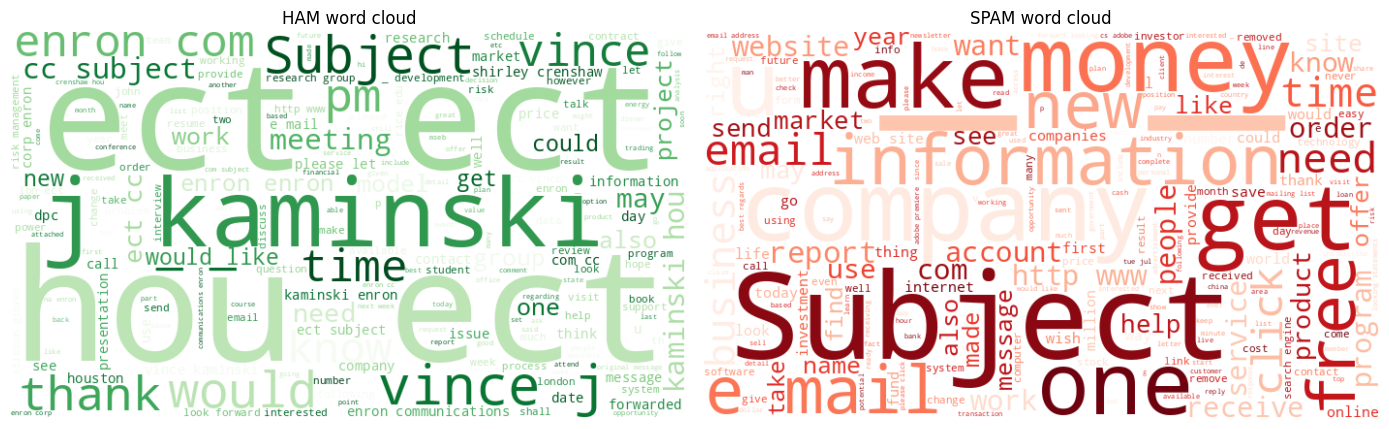

In [19]:
stop_words = set(nltk.corpus.stopwords.words("english"))

def collect_docs(label_value, n=1500):
    return " ".join(
        row["message"]
        for row in df.filter(F.col("label") == label_value).limit(n).collect()
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (lab, cmap) in zip(axes, [("ham", "Greens"), ("spam", "Reds")]):
    text_blob = collect_docs(lab)
    wc = WordCloud(
        width=700,
        height=400,
        background_color="white",
        stopwords=stop_words,
        colormap=cmap
    ).generate(text_blob)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{lab.upper()} word cloud")
    ax.axis("off")

plt.tight_layout()
plt.show()

## Step 16 — Hyperparameter tuning of the best model

We now tune the best-performing Naive Bayes variant with a small grid search over
`CountVectorizer.vocabSize` and `NaiveBayes.smoothing`, to see whether the baseline result
can be improved further.

In [20]:
from pyspark.ml.tuning import ParamGridBuilder, TrainValidationSplit

best_features_col = {
    "Multinomial NB": "features",
    "Bernoulli NB": "binary_features",
    "Gaussian NB": "features"
}[best_model_name]

best_model_type = {
    "Multinomial NB": "multinomial",
    "Bernoulli NB": "bernoulli",
    "Gaussian NB": "gaussian"
}[best_model_name]

tune_nb = NaiveBayes(
    featuresCol=best_features_col,
    labelCol="label_num",
    modelType=best_model_type
)

tune_pipeline = Pipeline(stages=[label_indexer, tokenizer, remover, cv, idf, binarizer, tune_nb])

param_grid = (
    ParamGridBuilder()
    .addGrid(cv.vocabSize, [2000, 5000, 10000])
    .addGrid(tune_nb.smoothing, [0.5, 1.0, 2.0])
    .build()
)

tune_evaluator = MulticlassClassificationEvaluator(
    labelCol="label_num",
    predictionCol="prediction",
    metricName="f1"
)

tvs = TrainValidationSplit(
    estimator=tune_pipeline,
    estimatorParamMaps=param_grid,
    evaluator=tune_evaluator,
    trainRatio=0.8,
    seed=42
)

tuned_model = tvs.fit(train_df)
tuned_pred = tuned_model.transform(test_df)

tuned_f1 = tune_evaluator.evaluate(tuned_pred)
baseline_f1 = summary_df.loc[best_model_name, "F1-score"]

print(f"Baseline {best_model_name} F1-score : {baseline_f1:.4f}")
print(f"Tuned {best_model_name} F1-score    : {tuned_f1:.4f}")

best_params = tuned_model.getEstimatorParamMaps()[np.argmax(tuned_model.validationMetrics)]
print("\nBest hyperparameters found:")
for param, value in best_params.items():
    print(f"  {param.name}: {value}")

Baseline Multinomial NB F1-score : 0.9881
Tuned Multinomial NB F1-score    : 0.9909

Best hyperparameters found:
  vocabSize: 10000
  smoothing: 2.0


## Step 17 — Key interpretation points

### What to notice and write up in the report
1. The Enron dataset is **imbalanced** — noticeably more ham than spam emails, so accuracy alone
   can be misleading and precision/recall/F1 matter more.
2. **Multinomial NB** typically performs strongly on text/TF–IDF data because it directly models
   term frequency, which is informative for spam detection.
3. **Bernoulli NB** only looks at whether a word appears at all; it can do well when the *presence*
   of certain trigger words (e.g. promotional or financial terms) is more informative than how
   often they repeat.
4. **Gaussian NB** assumes normally-distributed continuous features, which is a poor fit for sparse,
   skewed TF–IDF vectors — expect it to underperform the other two, and explain *why* in the report
   (violated distributional assumption) rather than just reporting the number.
5. Grid search over `vocabSize` and `smoothing` can improve F1-score, but not always dramatically —
   report both the baseline and tuned scores and comment on the difference.
6. Looking at **misclassified emails** and the **word clouds** is more useful for understanding model
   behaviour than a single headline metric.



In [21]:
# spark.stop()